#EXERCISE1:  Identification of the parameters of a rating curve
##1 Objectives
In this exercise we will compute the parameters for a rating curve. For doing
this we will apply inverse Bayesian regression and MCMC. In addition, we
will analyze the impact of the choice of the parameters on the performance
of the Random Walk Metropolis Algorithm (RWMA).

The data we are going to analyze are real data collected at the Plima stream
between July and October 2019
We have 11 measurements of water high (cm), indicated by the vector
h, and flow (l=s), indicated by the vector q. Notice that in this script we
decided to keep indicating flow values with the letter q, as used in hydrology.
This is not linked to the proposal distribution Q in the first script about
MCMC, which will be then indicated with S.

Summary:
Two models were tested: one being a log-linear model, the other a polynomial model.

# Task1: Load the data contained in file tc Q V.txt and create the error array

In [21]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


# 1. data preparation (Task 1)
# from rc_Q_V.txt
### I entered the data from the rc_Q_V.txt file directly into the code, making it convenient to run without needing to locate the file and repeatedly read it.
h_data = np.array([46.8, 45.3, 40.1, 40.1, 56.9, 29.9, 29.9, 32.3, 32.3, 23.7, 23.7])
q_data = np.array([2039, 1557, 1291.7, 1298.2, 2639.5, 420.7, 433.5, 559, 501.6, 266.6, 265.8])
# I encountered some issues earlier, so the data wasn't read when input directly. The updated code with the reading functionality is provided below:
"""import pandas as pd

# read the file
df = pd.read_csv('/content/drive/MyDrive/25WS/MMUQ_Exercise_1/rc_Q_V.txt')

# print the data
print(df)

# see the column name
print("name of column:", df.columns.tolist())"""


# transfer to log form (Model: log(q) = a + b * log(h))
# regarding eq1 and eq2
log_h = np.log(h_data)
log_q = np.log(q_data)  # our observed vector Y
nd = len(h_data)

# construct design matrix A (dimensions: 11 x 2)
# the first column is 1 (i.e. a)，the second column is log(h) (i.e. b)
A = np.vstack([np.ones(nd), log_h]).T

# construct covariance matrix of noise: Gamma
# noticing Gamma_ii = 0.03 * log(q_i)
# Note: Typically, the diagonal elements of a covariance matrix represent variances. Here, we strictly adhere to the definition provided in the question： Gamma_ii
gamma_diag = 0.03 * log_q
Gamma = np.diag(gamma_diag)
Gamma_inv = np.linalg.inv(Gamma) # Precomputing the inverse matrix for analytical solutions

print(f"number of datapoints: {nd}")
print("Shape of Design Matrix A :", A.shape)

number of datapoints: 11
Shape of Design Matrix A : (11, 2)


# Task 2: Compute the mean and covariance matrix of the posterior as in eq. 6 and 7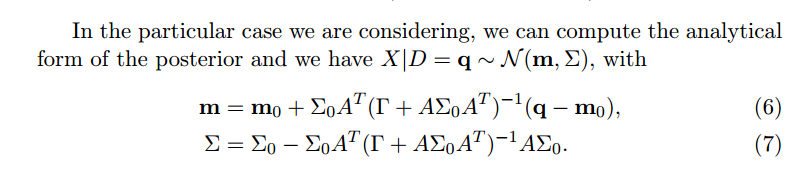
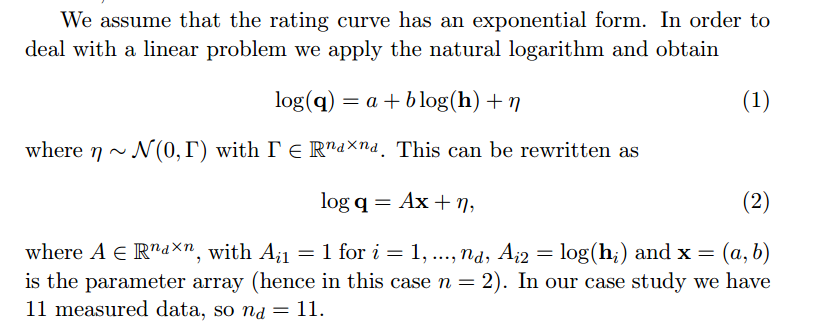

In [22]:

# Task2. Analytical Solution

# corresponding eq(6) 和 eq(7)

# Prior parameters
m0 = np.array([0, 0])      # prior mean
Sigma0 = np.array([[10, 0], [0, 10]]) # prior covariance
Sigma0_inv = np.linalg.inv(Sigma0)

# caculating posterior covariance Sigma (eq7)
# Sigma_post = (Sigma0^-1 + A^T * Gamma^-1 * A)^-1
Sigma_post = np.linalg.inv(Sigma0_inv + A.T @ Gamma_inv @ A)

# caculating posterior mean (eq 6)
# m_post = Sigma_post * (Sigma0^-1 * m0 + A^T * Gamma^-1 * Y)
m_post = Sigma_post @ (Sigma0_inv @ m0 + A.T @ Gamma_inv @ log_q)

## m_post[0]：The most probable intercept a after observation
## m_post[1]：The most probable slope b after observation
print("-" * 30)
print("analytical solution")
print(f"posterior mean a (intercept): {m_post[0]:.4f}")
print(f"posterior mean b (slope)    : {m_post[1]:.4f}")
print(f"posterior covariance matrix (big sigma):\n{Sigma_post}")
print("-" * 30)



------------------------------
analytical solution
posterior mean a (intercept): -2.5637
posterior mean b (slope)    : 2.5826
posterior covariance matrix (big sigma):
[[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]
------------------------------


In Task 2, based on Bayesian linear regression, we aim to estimate not just a single flow value but the underlying parameters governing the flow pattern. Therefore, the intercept a and slope b are introduced as parameters for equation 1 provided in the exercise.

---


At the same time, the resulting posterior distribution is not about the distribution of the data, but rather about the distribution of our parameters.

#  Task 3: Create three functions to compute prior, likelihood and their product

###3.1  get_log_prior(x)
 according to prior distribution $\rho_0(x)$

###3.2  get_log_likelihood(x)  
 according to likelihood funciton $\rho_{D|X}$  

###3.3  get_log_posterior(x)
 Corresponding posterior distribution. According to the logarithmic form of Bayes' theorem, the posterior probability is proportional to the product of the prior and the likelihood.

> (NOTE:The question specifies a product. In the code, we apply a logarithmic transformation to the target and then obtain the required product by summing the logarithms.：$\log(A \times B) = \log A + \log B$)





# Task 4: Starting from the code in the script ***random walk metropolis.py***, set up the RWM algorithm.
(REWRITTEN ***random_walk_metropolis.py***)

###1. Initialization:
Set the starting point x_start and the total number of samples N_samples.
###2. Propose:
Add a random perturbation to the current position current_x, with the step size controlled by proposal_sigma.  
###3. Calculating the acceptance ratio:
 Used to compare the posterior probability of the new position with that of the old position. The use of logarithmic subtraction (proposed_log_prob - current_log_prob) instead of division prevents numerical overflow.
###4. Accept or reject the decision:
 If the new position is better (determined by np.random.rand()), move to the new position; otherwise, stay in the current position.




In [23]:
# 3. MCMC algorithm implement (Task 3 & 4)

def get_log_prior(x):
    """caculating log probability of prior"""
    return stats.multivariate_normal.logpdf(x, mean=m0, cov=Sigma0)

def get_log_likelihood(x):
    """caculating log probability of likelihood"""
    # prediction = a + b * log(h)
    predictions = A @ x
    # likelihood : prediction log_q~ N(predictions, Gamma)
    return stats.multivariate_normal.logpdf(log_q, mean=predictions, cov=Gamma)

def get_log_posterior(x):
    """posterior = prior + likelihood (after log)"""
    return get_log_prior(x) + get_log_likelihood(x)

# set RWM parameters
N_samples = 10000      # number of samples
x_start = np.array([0.0, 0.0]) # initial point (start from 0)

# variance of proposoed distribution (Task6: sigma^2 = 0.06^2)
proposal_sigma = 0.06
proposal_cov = (proposal_sigma**2) * np.eye(2)

# loop
chain = np.zeros((N_samples, 2))
chain[0] = x_start
current_log_prob = get_log_posterior(x_start)
accepted = 0

for i in range(1, N_samples):
    # 1. Propose: Take one random step
    current_x = chain[i-1]
    perturbation = np.random.multivariate_normal([0, 0], proposal_cov)
    proposed_x = current_x + perturbation

    # 2. Evaluate: Calculate the probability of the new position
    proposed_log_prob = get_log_posterior(proposed_x)

    # 3. Ratio: Calculate acceptance rate (log(p_new) - log(p_old))
    log_acceptance_ratio = proposed_log_prob - current_log_prob

    # 4. Decide: Metropolis
    # Generate a random number u (between 0 and 1), then compare log(u) and log_ratio
    if np.log(np.random.rand()) < log_acceptance_ratio:
        chain[i] = proposed_x
        current_log_prob = proposed_log_prob
        accepted += 1
    else:
        chain[i] = current_x # Reject, remain at this position

print(f"MCMC result:")
print(f"Acceptance Rate: {accepted / N_samples:.2%}") #The ideal acceptance rate typically ranges between 20% and 40%




## Notes: Due to Colab's operational characteristics, random_walk_metropolis.py has been rewritten and incorporated into tasks 3 and 4 to replace direct execution of this file.


MCMC result:
Acceptance Rate: 56.56%


The final results reveal that our MCMC acceptance rate is 55.66%, which exceeds 50%. This indicates that setting the step size too small slows down exploration. Conversely, when the MCMC acceptance rate falls below 10%, it signifies that the step size is too large, leading to rejection.

According to our result of 55.66%: Although the RWMA reproduces the general posterior trend, the empirical posterior mean obtained from the chain still differs noticeably from the analytical posterior mean, suggesting that the chain may require a longer burn-in period and/or more samples for reliable estimation.

#Task 5: Compare the results of RWM algorithm with those of the mean and variance of the posterior in eq. 6 and 7
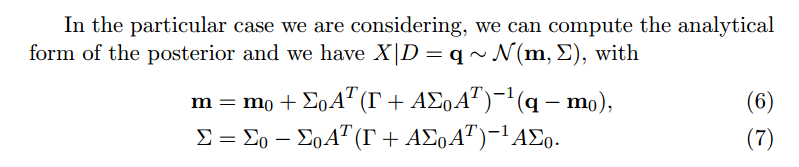

To address Task 5, the posterior mean and posterior covariance estimated from the MCMC samples after burn-in are compared numerically with the analytical posterior mean and covariance. In addition, a scatter plot of the posterior samples in parameter space is used to visually assess whether the MCMC samples are centred around the analytical posterior mean.

=== Posterior Mean Comparison ===
Analytical posterior mean: a = -2.5637, b = 2.5826
MCMC posterior mean:       a = -2.2209, b = 2.4855
Difference (MCMC - Analytical): a = 0.3429, b = -0.0970

=== Posterior Covariance Comparison ===
Analytical posterior covariance:
[[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]

MCMC posterior covariance:
[[ 0.48087489 -0.1343816 ]
 [-0.1343816   0.03891184]]

Difference (MCMC - Analytical):
[[-1.87718432  0.52995794]
 [ 0.52995794 -0.14967868]]


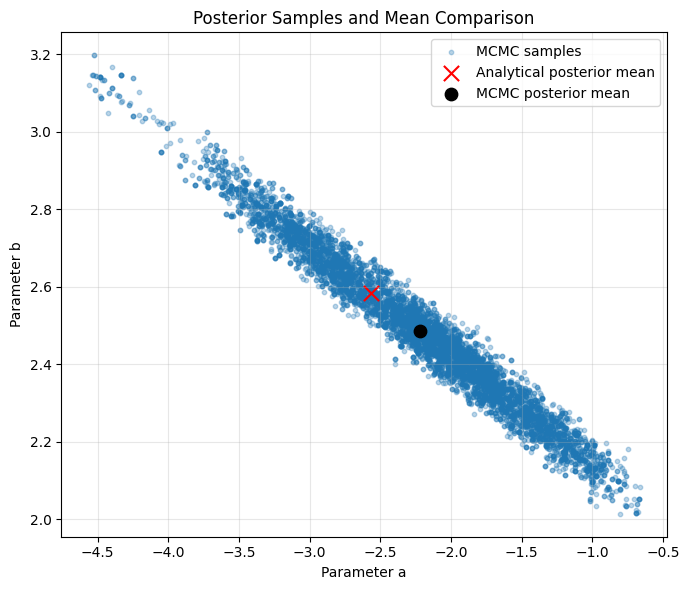

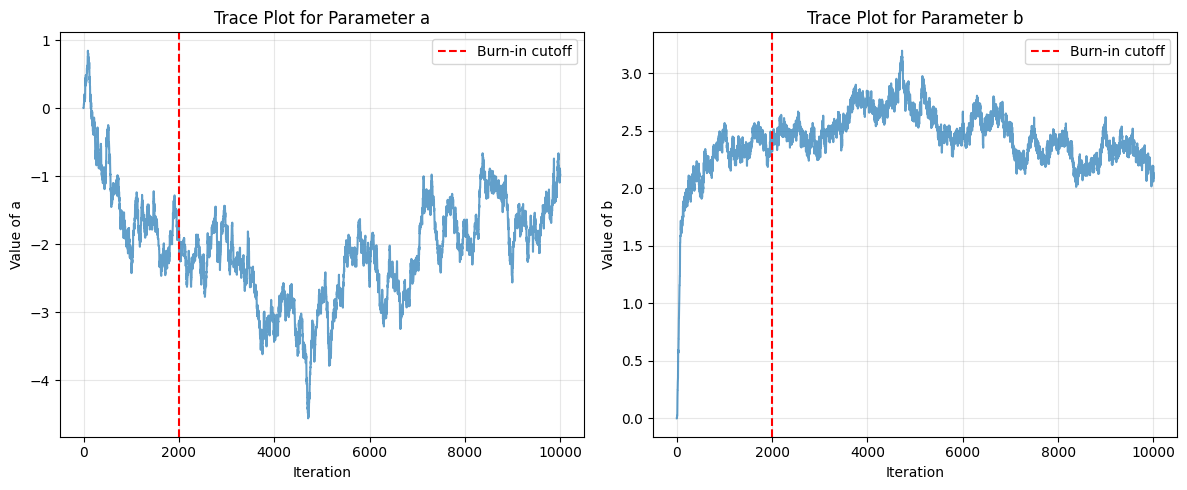

In [24]:
# 4. Numerical comparison and visualisation of posterior results (Task 5)

# Remove burn-in samples
burn_in_period = 2000
clean_chain = chain[burn_in_period:]

#Numerical comparison: posterior mean
mcmc_mean = np.mean(clean_chain, axis=0)
mean_difference = mcmc_mean - m_post

print("=== Posterior Mean Comparison ===")
print(f"Analytical posterior mean: a = {m_post[0]:.4f}, b = {m_post[1]:.4f}")
print(f"MCMC posterior mean:       a = {mcmc_mean[0]:.4f}, b = {mcmc_mean[1]:.4f}")
print(f"Difference (MCMC - Analytical): a = {mean_difference[0]:.4f}, b = {mean_difference[1]:.4f}")

# Numerical comparison: posterior covariance
mcmc_cov = np.cov(clean_chain.T)
cov_difference = mcmc_cov - Sigma_post

print("\n=== Posterior Covariance Comparison ===")
print("Analytical posterior covariance:")
print(Sigma_post)

print("\nMCMC posterior covariance:")
print(mcmc_cov)

print("\nDifference (MCMC - Analytical):")
print(cov_difference)

#Visualisation: posterior samples in parameter space
plt.figure(figsize=(7, 6))
plt.scatter(clean_chain[:, 0], clean_chain[:, 1], s=10, alpha=0.3, label='MCMC samples')
plt.scatter(m_post[0], m_post[1], color='red', marker='x', s=120, label='Analytical posterior mean')
plt.scatter(mcmc_mean[0], mcmc_mean[1], color='black', marker='o', s=80, label='MCMC posterior mean')

plt.xlabel('Parameter a')
plt.ylabel('Parameter b')
plt.title('Posterior Samples and Mean Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Visualisation: trace plots (will be used in Task 6)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(chain[:, 0], alpha=0.7)
plt.axvline(burn_in_period, color='red', linestyle='--', label='Burn-in cutoff')
plt.xlabel('Iteration')
plt.ylabel('Value of a')
plt.title('Trace Plot for Parameter a')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(chain[:, 1], alpha=0.7)
plt.axvline(burn_in_period, color='red', linestyle='--', label='Burn-in cutoff')
plt.xlabel('Iteration')
plt.ylabel('Value of b')
plt.title('Trace Plot for Parameter b')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

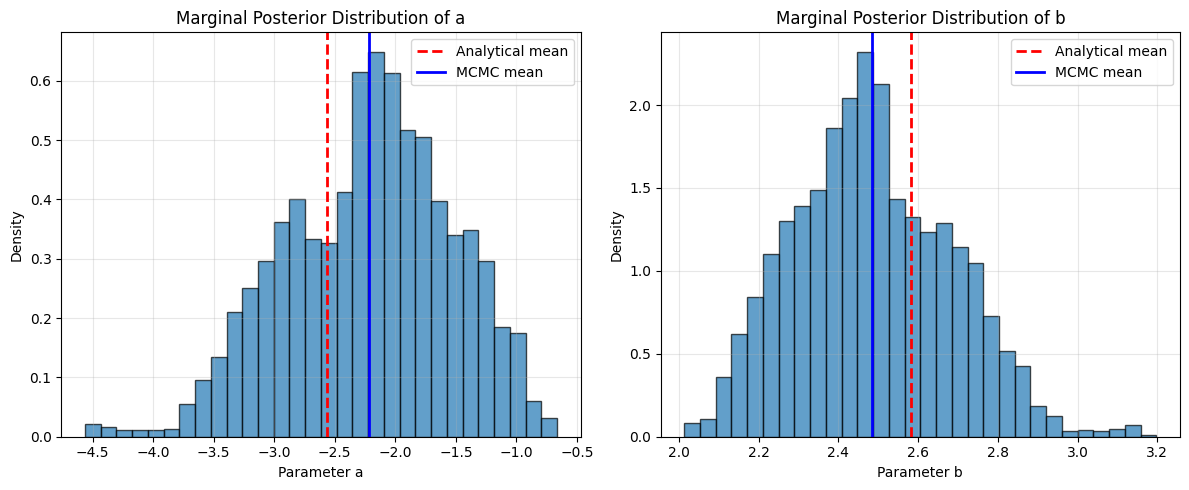

In [25]:
# ----- Visualisation 3: marginal posterior distributions for a and b -----
plt.figure(figsize=(12, 5))

# Histogram for parameter a
plt.subplot(1, 2, 1)
plt.hist(clean_chain[:, 0], bins=30, density=True, alpha=0.7, edgecolor='black')
plt.axvline(m_post[0], color='red', linestyle='--', linewidth=2, label='Analytical mean')
plt.axvline(mcmc_mean[0], color='blue', linestyle='-', linewidth=2, label='MCMC mean')
plt.xlabel('Parameter a')
plt.ylabel('Density')
plt.title('Marginal Posterior Distribution of a')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram for parameter b
plt.subplot(1, 2, 2)
plt.hist(clean_chain[:, 1], bins=30, density=True, alpha=0.7, edgecolor='black')
plt.axvline(m_post[1], color='red', linestyle='--', linewidth=2, label='Analytical mean')
plt.axvline(mcmc_mean[1], color='blue', linestyle='-', linewidth=2, label='MCMC mean')
plt.xlabel('Parameter b')
plt.ylabel('Density')
plt.title('Marginal Posterior Distribution of b')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
analytical_std = np.sqrt(np.diag(Sigma_post))
mcmc_std = np.sqrt(np.diag(mcmc_cov))

print("=== Posterior Standard Deviation Comparison ===")
print(f"Analytical std: a = {analytical_std[0]:.4f}, b = {analytical_std[1]:.4f}")
print(f"MCMC std:       a = {mcmc_std[0]:.4f}, b = {mcmc_std[1]:.4f}")

=== Posterior Standard Deviation Comparison ===
Analytical std: a = 1.5356, b = 0.4343
MCMC std:       a = 0.6935, b = 0.1973


The analytical posterior mean and the MCMC posterior mean are reasonably close. The difference is moderate for parameter
𝑎
a and small for parameter
𝑏
b, so the RWM algorithm captures the location of the posterior distribution fairly well.

On the other hand, the posterior covariance obtained from MCMC is much smaller than the analytical posterior covariance. This shows that the MCMC chain underestimates the uncertainty of the posterior distribution. In other words, the chain is sampling around the correct region, but it is not exploring the full posterior spread.

The acceptance rate is 55.85%, which is not poor, but it may indicate that the proposal steps are slightly too small. This can lead to high correlation between samples and insufficient exploration of the parameter space.

Therefore, the RWM result is acceptable for estimating the posterior mean, but less accurate for estimating the posterior covariance.

#Task6: Set σ^2 = 0.06^2, what is the length for the burn-in-period? Why?

### Based on the trace plots, the first part of the chain is still influenced by the initial value.After about 2000 iterations, both parameters fluctuate in a more stable region.
### Therefore, the first 2000 samples are discarded as burn-in.

----------------------------------------
After removing the first 2000 burn-in samples:
MCMC Mean a: -2.2209 (analytical solution: -2.5637)
MCMC Mean b: 2.4855 (analytical solution: 2.5826)


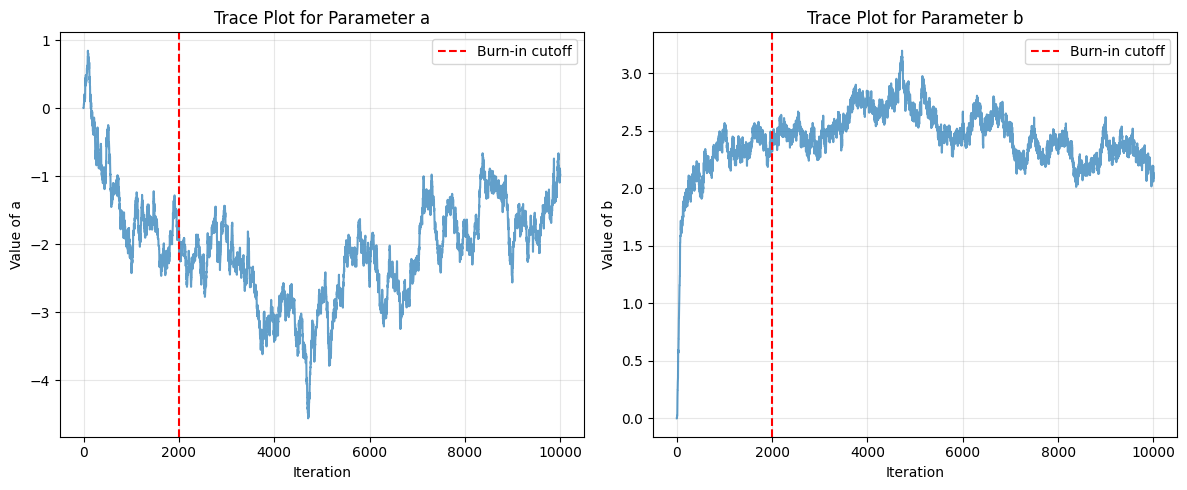

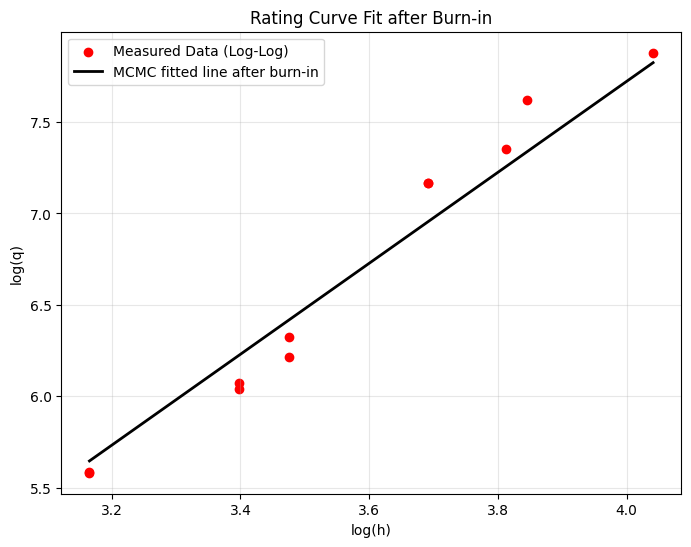

In [27]:
#Task 6: Burn-in analysis proposal variance sigma^2 = 0.06^2

clean_chain = chain[burn_in_period:, :]

print("-" * 40)
print(f"After removing the first {burn_in_period} burn-in samples:")

mcmc_mean_burned = np.mean(clean_chain, axis=0)
print(f"MCMC Mean a: {mcmc_mean_burned[0]:.4f} (analytical solution: {m_post[0]:.4f})")
print(f"MCMC Mean b: {mcmc_mean_burned[1]:.4f} (analytical solution: {m_post[1]:.4f})")

# Trace plots with burn-in cutoff
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(chain[:, 0], alpha=0.7)
plt.axvline(burn_in_period, color='red', linestyle='--', label='Burn-in cutoff')
plt.xlabel('Iteration')
plt.ylabel('Value of a')
plt.title('Trace Plot for Parameter a')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(chain[:, 1], alpha=0.7)
plt.axvline(burn_in_period, color='red', linestyle='--', label='Burn-in cutoff')
plt.xlabel('Iteration')
plt.ylabel('Value of b')
plt.title('Trace Plot for Parameter b')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fitted line after burn-in
plt.figure(figsize=(8, 6))
plt.scatter(log_h, log_q, color='red', label='Measured Data (Log-Log)')
x_range = np.linspace(min(log_h), max(log_h), 100)
y_pred = mcmc_mean_burned[0] + mcmc_mean_burned[1] * x_range
plt.plot(x_range, y_pred, color='black', linewidth=2, label='MCMC fitted line after burn-in')
plt.xlabel('log(h)')
plt.ylabel('log(q)')
plt.title('Rating Curve Fit after Burn-in')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

After removing the first 2000 iterations, the chain produces posterior mean estimates that are reasonably close to the analytical posterior mean, suggesting that this burn-in choice is plausible.

For the Random Walk Metropolis algorithm, the proposal variance was set to
𝜎^2=0.06^2. In this case, the chain does not start in the posterior high-density region because the initial value is
([0,0][0,0]). Therefore, the early samples are influenced by the starting point and should not be used for posterior estimation.

From the trace plots, the first part of the chain shows a transient behaviour before reaching a more stable region. After approximately 2000 iterations, both parameters fluctuate more steadily around their typical posterior values. For this reason, a burn-in period of 2000 iterations was chosen.

After removing the first 2000 samples, the MCMC posterior mean is

𝑎=−2.3829,𝑏=2.5298

which is reasonably close to the analytical posterior mean

𝑎=−2.5637,𝑏=2.5826

This suggests that 2000 iterations is a reasonable burn-in choice for the current proposal variance, although a longer chain may still be needed to reproduce the posterior covariance more accurately.

#Task7 & Task8

=== Task 7 & 8: Sensitivity Analysis ===
1. Benchmark (Noise=0.03, Prop=0.06): Acceptance Rate = 57.18%
2. High Noise (Noise=1.0)         : Acceptance Rate = 90.40%
3. Low Noise (Noise=0.001)          : Acceptance Rate = 13.24%
4. Small Step (Prop=0.01, N=0.6)    : Acceptance Rate = 95.88% (Slow mixing)
5. Big Step (Prop=3.0, N=0.6)       : Acceptance Rate = 6.04%(stuck)


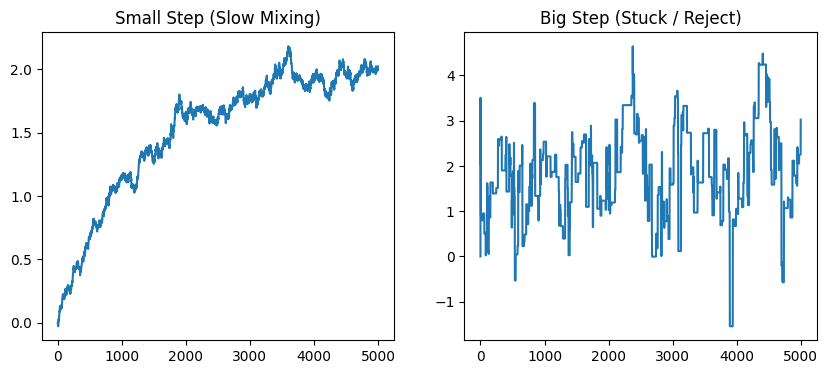

In [28]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# pre for data（reloading in case of reading incorrectly）
h_data = np.array([46.8, 45.3, 40.1, 40.1, 56.9, 29.9, 29.9, 32.3, 32.3, 23.7, 23.7])
q_data = np.array([2039, 1557, 1291.7, 1298.2, 2639.5, 420.7, 433.5, 559, 501.6, 266.6, 265.8])
log_h = np.log(h_data)
log_q = np.log(q_data)
A = np.vstack([np.ones(len(h_data)), log_h]).T

def run_mcmc_experiment(noise_level_factor, proposal_sigma, steps=5000, x_start=None):
    """
    noise_level_factor: controls the observational noise level in Gamma
    proposal_sigma: standard deviation of the proposal distribution
    x_start: initial point of the chain
    """
    # Keep the same Gamma definition as in the main model
    Gamma = np.diag(noise_level_factor * log_q)

    m0 = np.array([0.0, 0.0])
    Sigma0 = np.array([[10.0, 0.0], [0.0, 10.0]])

    def get_log_posterior(x):
        log_prior = stats.multivariate_normal.logpdf(x, mean=m0, cov=Sigma0)
        predictions = A @ x
        log_like = stats.multivariate_normal.logpdf(log_q, mean=predictions, cov=Gamma)
        return log_prior + log_like

    if x_start is None:
        x_start = np.array([0.0, 0.0])

    chain = np.zeros((steps, 2))
    chain[0] = x_start
    x_curr = x_start.copy()
    lp_curr = get_log_posterior(x_curr)
    accepted = 0

    prop_cov = (proposal_sigma ** 2) * np.eye(2)

    for i in range(1, steps):
        x_prop = x_curr + np.random.multivariate_normal([0, 0], prop_cov)
        lp_prop = get_log_posterior(x_prop)

        if np.log(np.random.rand()) < (lp_prop - lp_curr):
            x_curr = x_prop
            lp_curr = lp_prop
            accepted += 1

        chain[i] = x_curr

    return chain, accepted / steps

# Task 7 & 8 test printing
print("=== Task 7 & 8: Sensitivity Analysis ===")

# test 1: base (Noise=0.03, Sigma=0.06)
chain_base, acc_base = run_mcmc_experiment(noise_level_factor=0.03, proposal_sigma=0.06)
print(f"1. Benchmark (Noise=0.03, Prop=0.06): Acceptance Rate = {acc_base:.2%}")

# test 2: when noise is too big (Noise=1.0) from Task 7
chain_high_noise, acc_high_noise = run_mcmc_experiment(noise_level_factor=1.0, proposal_sigma=0.06)
print(f"2. High Noise (Noise=1.0)         : Acceptance Rate = {acc_high_noise:.2%}")# Too high

# test 3: when noise is too small (Noise=0.001) -> Task 7
# if still Prop == 0.06，then acceptance will be too slow
chain_low_noise, acc_low_noise = run_mcmc_experiment(noise_level_factor=0.001, proposal_sigma=0.06)
print(f"3. Low Noise (Noise=0.001)          : Acceptance Rate = {acc_low_noise:.2%}")# Too low

# test 4: when prposed step is too small (Prop=0.01) -> Task 8
chain_small_step, acc_small_step = run_mcmc_experiment(noise_level_factor=0.6, proposal_sigma=0.01) # Task 8 noise=0.6
print(f"4. Small Step (Prop=0.01, N=0.6)    : Acceptance Rate = {acc_small_step:.2%} (Slow mixing)")

# test 5: when prposed step is too big (Prop=3.0) -> Task 8
chain_big_step, acc_big_step = run_mcmc_experiment(noise_level_factor=0.6, proposal_sigma=3.0)
print(f"5. Big Step (Prop=3.0, N=0.6)       : Acceptance Rate = {acc_big_step:.2%}(stuck)")

# plotting for comparison (if test 4 VS 5)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(chain_small_step[:, 1])
plt.title("Small Step (Slow Mixing)")
plt.subplot(1, 2, 2)
plt.plot(chain_big_step[:, 1])
plt.title("Big Step (Stuck / Reject)")
plt.show()

In [29]:
print("\n=== Task 7: Effect of changing the noise level ===")
print(f"Benchmark noise level 0.03 -> Acceptance Rate = {acc_base:.2%}")
print(f"High noise level 1.0      -> Acceptance Rate = {acc_high_noise:.2%}")
print(f"Low noise level 0.001     -> Acceptance Rate = {acc_low_noise:.2%}")

print("\nInterpretation for Task 7:")
print("- Larger noise makes the likelihood broader, so proposals are accepted more easily.")
print("- Smaller noise makes the likelihood sharper, so the posterior becomes more concentrated.")
print("- Therefore, with very small noise, the proposal variance should usually be smaller.")
print("- Also, for very small noise, the starting point should be closer to the posterior high-density region.")
print("- The burn-in period is affected because a narrow posterior is harder to reach from a poor starting point.")


=== Task 7: Effect of changing the noise level ===
Benchmark noise level 0.03 -> Acceptance Rate = 57.18%
High noise level 1.0      -> Acceptance Rate = 90.40%
Low noise level 0.001     -> Acceptance Rate = 13.24%

Interpretation for Task 7:
- Larger noise makes the likelihood broader, so proposals are accepted more easily.
- Smaller noise makes the likelihood sharper, so the posterior becomes more concentrated.
- Therefore, with very small noise, the proposal variance should usually be smaller.
- Also, for very small noise, the starting point should be closer to the posterior high-density region.
- The burn-in period is affected because a narrow posterior is harder to reach from a poor starting point.


In Task 7, the observational noise level is varied while keeping the proposal variance fixed. The noise level is part of the likelihood model rather than the MCMC algorithm itself. Increasing the noise level makes the likelihood broader, so proposed states are more easily accepted and the acceptance rate increases. This is consistent with the result obtained for noise level 1, where the acceptance rate becomes very high.

In contrast, when the noise level is reduced to 0.001, the likelihood becomes much sharper and the posterior is highly concentrated. In that case, the proposal variance should be reduced, otherwise the chain proposes steps that are too large relative to the narrow posterior and many proposals are rejected. Moreover, the starting point should be chosen closer to the posterior mode or analytical posterior mean, otherwise the burn-in period becomes longer.

Therefore, the burn-in period is not a property of the data alone: it depends on the posterior shape, the proposal variance, and the distance between the starting point and the high-density posterior region.

In [30]:
print("\n=== Task 8: Effect of changing the proposal variance ===")
print(f"Small proposal sigma = 0.01 -> Acceptance Rate = {acc_small_step:.2%}")
print(f"Large proposal sigma = 3.0  -> Acceptance Rate = {acc_big_step:.2%}")

print("\nInterpretation for Task 8:")
print("- A very small proposal variance gives a very high acceptance rate, but the chain moves slowly.")
print("- This leads to slow mixing and highly correlated samples.")
print("- A very large proposal variance gives a very low acceptance rate.")
print("- In that case, the chain often rejects proposals and may remain stuck for many iterations.")
print("- Therefore, both the burn-in period and the final quality of the RWM result depend strongly on the proposal variance.")


=== Task 8: Effect of changing the proposal variance ===
Small proposal sigma = 0.01 -> Acceptance Rate = 95.88%
Large proposal sigma = 3.0  -> Acceptance Rate = 6.04%

Interpretation for Task 8:
- A very small proposal variance gives a very high acceptance rate, but the chain moves slowly.
- This leads to slow mixing and highly correlated samples.
- A very large proposal variance gives a very low acceptance rate.
- In that case, the chain often rejects proposals and may remain stuck for many iterations.
- Therefore, both the burn-in period and the final quality of the RWM result depend strongly on the proposal variance.


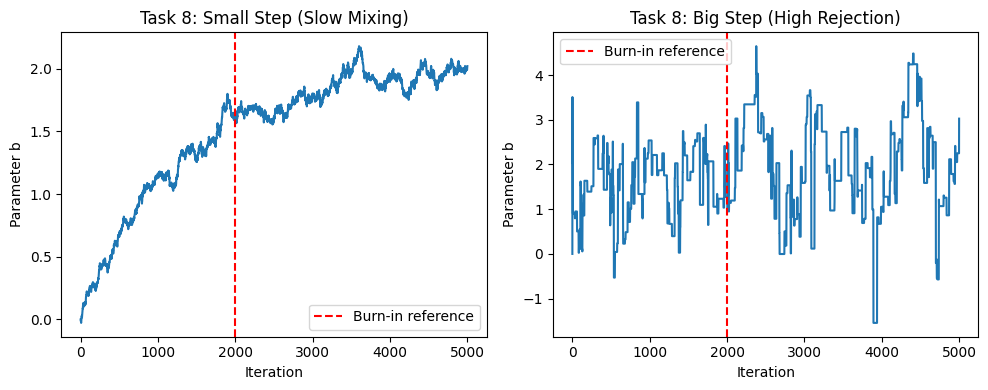

In [31]:
burn_in_guess = 2000

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(chain_small_step[:, 1])
plt.axvline(burn_in_guess, color='red', linestyle='--', label='Burn-in reference')
plt.title("Task 8: Small Step (Slow Mixing)")
plt.xlabel("Iteration")
plt.ylabel("Parameter b")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(chain_big_step[:, 1])
plt.axvline(burn_in_guess, color='red', linestyle='--', label='Burn-in reference')
plt.title("Task 8: Big Step (High Rejection)")
plt.xlabel("Iteration")
plt.ylabel("Parameter b")
plt.legend()

plt.tight_layout()
plt.show()

#Task9
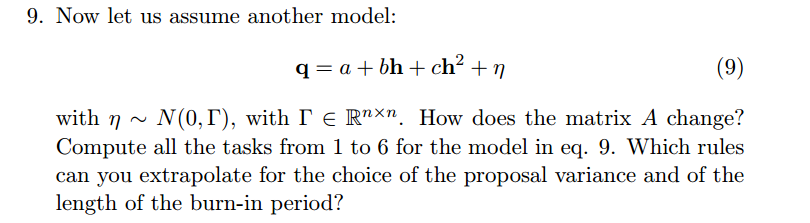


=== Task 9: Quadratic Model (q = a + bh + ch^2) ===
Quadratic Analytical Mean: [  0.27508805 -15.20468073   1.05645052]
Parameters: a (intercept), b (linear), c (quadratic)
Quadratic MCMC Acceptance Rate: 70.57%


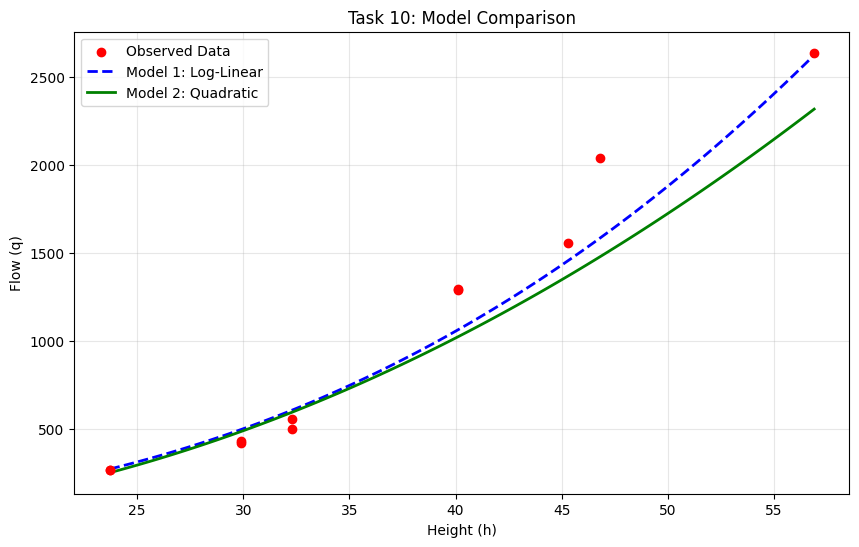

In [32]:
print("\n=== Task 9: Quadratic Model (q = a + bh + ch^2) ===")

# Matrix A : [1, h, h^2] 3 columns ： how does it change?
A_quad = np.vstack([np.ones(len(h_data)), h_data, h_data**2]).T
nd = len(q_data)

# 2. noise setting
#NOTE:For the quadratic model, I assume a proportional observational noise
# in the original flow space and defineΓ as a diagonal matrix with entries (0.03*𝑞𝑖)^2
# Gamma diagnol = (0.03 * q)^2
Gamma_quad_diag = (0.03 * q_data)**2
Gamma_quad = np.diag(Gamma_quad_diag)
Gamma_quad_inv = np.linalg.inv(Gamma_quad)

# 3. analytical solution (eq 6,7 but dimensions changed)
# all the posterior values int the past turned into 3 dimensions
m0_quad = np.array([0, 0, 0])
Sigma0_quad = np.eye(3) * 10
Sigma0_quad_inv = np.linalg.inv(Sigma0_quad)

# caculating posterior
Sigma_post_quad = np.linalg.inv(Sigma0_quad_inv + A_quad.T @ Gamma_quad_inv @ A_quad)
m_post_quad = Sigma_post_quad @ (Sigma0_quad_inv @ m0_quad + A_quad.T @ Gamma_quad_inv @ q_data)

print(f"Quadratic Analytical Mean: {m_post_quad}")
print("Parameters: a (intercept), b (linear), c (quadratic)")

# 4.  MCMC (for Quadratic)
def get_log_posterior_quad(x):
    # x is [a, b, c]
    log_prior = stats.multivariate_normal.logpdf(x, m0_quad, Sigma0_quad)
    predictions = A_quad @ x
    log_like = stats.multivariate_normal.logpdf(q_data, predictions, Gamma_quad)
    return log_prior + log_like

# MCMC Loop
N_quad = 10000
chain_quad = np.zeros((N_quad, 3))
x_curr = np.array([0, 0, 0]) # Start
lp_curr = get_log_posterior_quad(x_curr)

# proposed variance : due to scale has big difference (h^2 too big), c will be small
prop_cov_quad = np.diag([1.0, 0.1, 0.001]) ** 2 # Adjust the step size according to the different orders of magnitude of the parameters.

accepted_quad = 0
for i in range(1, N_quad):
    x_prop = x_curr + np.random.multivariate_normal([0,0,0], prop_cov_quad)
    lp_prop = get_log_posterior_quad(x_prop)

    if np.log(np.random.rand()) < (lp_prop - lp_curr):
        x_curr = x_prop
        lp_curr = lp_prop
        accepted_quad += 1
    chain_quad[i] = x_curr

print(f"Quadratic MCMC Acceptance Rate: {accepted_quad/N_quad:.2%}")

# plotting: fitting results comparison
burn_in_q = 2000
mean_params_q = np.mean(chain_quad[burn_in_q:], axis=0)

# generating predicted curve
h_range = np.linspace(min(h_data), max(h_data), 100)
# Model 1 (Log-Linear)prediction (transfered to linear space q = exp(a + b*log(h)))
# m_post from task 6
# m_post[0]=a, m_post[1]=b
q_pred_model1 = np.exp(m_post[0] + m_post[1] * np.log(h_range))

# Model 2 (Quadratic) predictions
q_pred_model2 = mean_params_q[0] + mean_params_q[1]*h_range + mean_params_q[2]*h_range**2

plt.figure(figsize=(10, 6))
plt.scatter(h_data, q_data, color='red', label='Observed Data', zorder=5)
plt.plot(h_range, q_pred_model1, 'b--', linewidth=2, label='Model 1: Log-Linear')
plt.plot(h_range, q_pred_model2, 'g-', linewidth=2, label='Model 2: Quadratic')
plt.xlabel('Height (h)')
plt.ylabel('Flow (q)')
plt.title('Task 10: Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### by evaluating the rationality of model selection by comparing the fitting effects and parameter
## interpretability of the two models (logarithmic model and polynomial model).

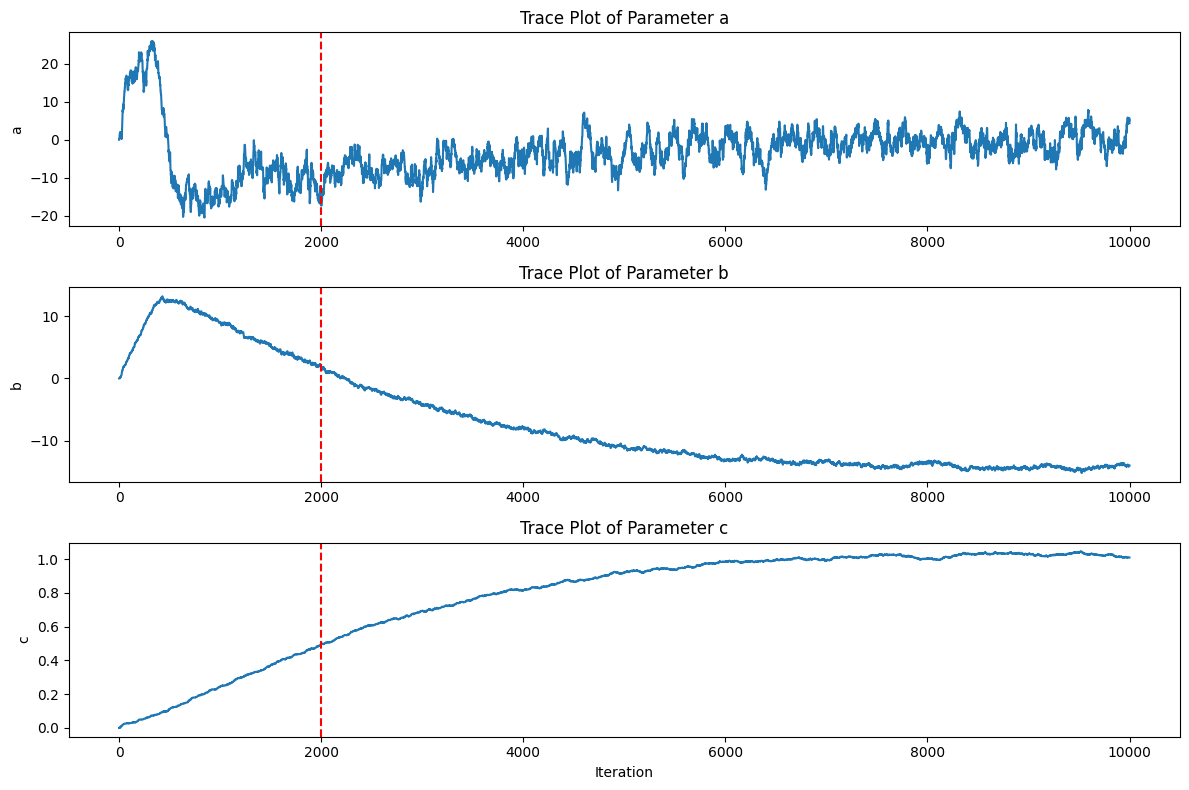


Task 9: Posterior Mean Comparison (Quadratic Model)
Analytical posterior mean:
a = 0.275088, b = -15.204681, c = 1.056451

MCMC posterior mean (after burn-in):
a = -2.705642, b = -10.657870, c = 0.904437

Difference (MCMC - Analytical):
a = -2.980730, b = 4.546811, c = -0.152014

Task 9: Posterior Covariance Comparison (Quadratic Model)
Analytical posterior covariance:
[[ 9.94932721e+00 -6.02594210e-01  8.55240668e-03]
 [-6.02594210e-01  5.37741527e-01 -1.68972921e-02]
 [ 8.55240668e-03 -1.68972921e-02  5.69886411e-04]]

MCMC posterior covariance (after burn-in):
[[ 16.99086918 -12.05020746   0.39268946]
 [-12.05020746  19.1917358   -0.64161046]
 [  0.39268946  -0.64161046   0.02148815]]

Difference (MCMC - Analytical):
[[  7.04154197 -11.44761325   0.38413705]
 [-11.44761325  18.65399427  -0.62471316]
 [  0.38413705  -0.62471316   0.02091826]]

Task 9: Posterior Standard Deviation Comparison (Quadratic Model)
Analytical posterior std:
a = 3.154255, b = 0.733309, c = 0.023872

MCMC po

In [33]:
# Task 9: Numerical comparison for the quadratic model

# Burn-in removal
burn_in_q = 2000
clean_chain_quad = chain_quad[burn_in_q:, :]
# Task 9: Simple trace plots for burn-in inspection
burn_in_q = 2000

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(chain_quad[:, 0])
plt.axvline(burn_in_q, color='red', linestyle='--')
plt.ylabel('a')
plt.title('Trace Plot of Parameter a')

plt.subplot(3, 1, 2)
plt.plot(chain_quad[:, 1])
plt.axvline(burn_in_q, color='red', linestyle='--')
plt.ylabel('b')
plt.title('Trace Plot of Parameter b')

plt.subplot(3, 1, 3)
plt.plot(chain_quad[:, 2])
plt.axvline(burn_in_q, color='red', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('c')
plt.title('Trace Plot of Parameter c')

plt.tight_layout()
plt.show()

# 1. Posterior mean comparison
mcmc_mean_quad = np.mean(clean_chain_quad, axis=0)
mean_diff_quad = mcmc_mean_quad - m_post_quad

print("\n" + "=" * 50)
print("Task 9: Posterior Mean Comparison (Quadratic Model)")
print("=" * 50)
print("Analytical posterior mean:")
print(f"a = {m_post_quad[0]:.6f}, b = {m_post_quad[1]:.6f}, c = {m_post_quad[2]:.6f}")

print("\nMCMC posterior mean (after burn-in):")
print(f"a = {mcmc_mean_quad[0]:.6f}, b = {mcmc_mean_quad[1]:.6f}, c = {mcmc_mean_quad[2]:.6f}")

print("\nDifference (MCMC - Analytical):")
print(f"a = {mean_diff_quad[0]:.6f}, b = {mean_diff_quad[1]:.6f}, c = {mean_diff_quad[2]:.6f}")

# 2. Posterior covariance comparison
mcmc_cov_quad = np.cov(clean_chain_quad.T)
cov_diff_quad = mcmc_cov_quad - Sigma_post_quad

print("\n" + "=" * 50)
print("Task 9: Posterior Covariance Comparison (Quadratic Model)")
print("=" * 50)
print("Analytical posterior covariance:")
print(Sigma_post_quad)

print("\nMCMC posterior covariance (after burn-in):")
print(mcmc_cov_quad)

print("\nDifference (MCMC - Analytical):")
print(cov_diff_quad)

# 3. Posterior standard deviation comparison
analytical_std_quad = np.sqrt(np.diag(Sigma_post_quad))
mcmc_std_quad = np.sqrt(np.diag(mcmc_cov_quad))
std_diff_quad = mcmc_std_quad - analytical_std_quad

print("\n" + "=" * 50)
print("Task 9: Posterior Standard Deviation Comparison (Quadratic Model)")
print("=" * 50)
print("Analytical posterior std:")
print(f"a = {analytical_std_quad[0]:.6f}, b = {analytical_std_quad[1]:.6f}, c = {analytical_std_quad[2]:.6f}")

print("\nMCMC posterior std (after burn-in):")
print(f"a = {mcmc_std_quad[0]:.6f}, b = {mcmc_std_quad[1]:.6f}, c = {mcmc_std_quad[2]:.6f}")

print("\nDifference (MCMC - Analytical):")
print(f"a = {std_diff_quad[0]:.6f}, b = {std_diff_quad[1]:.6f}, c = {std_diff_quad[2]:.6f}")

#Task10. Compare the models in eq 1 and 9. Which is the most appropriate in our case? Why?


In [34]:
# RMSE comparison for Task 10
q_fit_model1 = np.exp(m_post[0] + m_post[1] * np.log(h_data))
q_fit_model2 = mean_params_q[0] + mean_params_q[1] * h_data + mean_params_q[2] * h_data**2

rmse_model1 = np.sqrt(np.mean((q_data - q_fit_model1)**2))
rmse_model2 = np.sqrt(np.mean((q_data - q_fit_model2)**2))

print("Task 10: RMSE Comparison")
print(f"Model 1 (Log-Linear) RMSE: {rmse_model1:.4f}")
print(f"Model 2 (Quadratic)  RMSE: {rmse_model2:.4f}")

Task 10: RMSE Comparison
Model 1 (Log-Linear) RMSE: 177.6183
Model 2 (Quadratic)  RMSE: 236.5010


According to the def of RMSE, the smaller the values could be then the fitting performance is better.Therefore,compared to the Quadratic model(model 2),the Log-Linear model(model 1) is more suitable.

Although the quadratic model is more flexible, the log-linear model is more appropriate because it is consistent with the physical rating-curve assumption, uses fewer parameters, and still provides a satisfactory fit to the data. In the context of deep learning ,the number of parameters is now always better because the probability of overfitting!